# Introduction to Pandas


## What is Pandas

- Pandas is built on top of Python
- Two main data structures:
    - `DataFrame`
    - `Series`
 
A `DataFrame` is like a spreadsheet, a two-dimensional labelled data structure with columns of potentially different types.
A `Series` is a single column of a `DataFrame`, similar to an Excel column. But we can deal with a series as an object in its own right, especially when we have a single series of data. Notice that, unlike Python's built-in list, we can refer to items in a series by a `label`.




### Key Differences Between Pandas and Excel

| Feature                 | Pandas                                                      | Excel                                                       |
|-------------------------|-------------------------------------------------------------|-------------------------------------------------------------|
| Data Structure          | DataFrame, Series                                           | Worksheet, Range                                            |
| Handling Large Datasets | Designed for efficient manipulation of large data sets      | Can become slow with very large datasets                    |
| Programming             | Requires Python programming                                 | Mostly GUI-based with formulas/VBA for automation           |
| Data Analysis           | Extensive built-in functions for statistical analysis       | Basic built-in functions, external add-ins for advanced use |
| Data Visualization      | Integrated with Matplotlib, Seaborn for plots and graphs    | Built-in charting tools, less customizable                  |
| File Formats            | Supports multiple formats (CSV, Excel, JSON, SQL, etc.)     | Primarily Excel formats (XLSX, XLS), limited external formats|
| Real-time Data          | Can easily handle real-time data with updates               | Not designed for real-time data processing                  |
| Collaboration           | Code and results easily shared via notebooks (e.g., Jupyter)| Direct file sharing, issues with version control            |



### Transitioning from Excel to Pandas

- **Reading and Writing Data**: In pandas, reading from and writing to various file formats is straightforward. For example, `pd.read_csv('file.csv')` to read a CSV file into a DataFrame, akin to opening a CSV with Excel.

- **Data Manipulation**: Unlike Excel, where data manipulation is done through formulas or VBA scripts, pandas uses Python code. Filtering, sorting, and aggregating data through method calls on DataFrame objects.

- **Automation and Reproducibility**: Pandas, with Python, allows for the automation of data processing scripts, making repetitive tasks more efficient and less prone to error compared to manual operations in Excel.

#### Example: Filtering Data

- **Excel**: Apply a filter to a column using the GUI or use a formula like `=FILTER(range, criteria)`.
- **Pandas**: Use `df[df['column_name'] > value]` to filter rows based on column values.

#### Sample Data in Excel-like Sheet

Imagine this is a snippet of an Excel spreadsheet:

| Date       | Product    | Quantity | Price |
|------------|------------|----------|-------|
| 2024-02-01 | Product A  | 10       | 20    |
| 2024-02-01 | Product B  | 15       | 25    |
| 2024-02-02 | Product A  | 5        | 20    |
| 2024-02-02 | Product B  | 7        | 25    |

To access data in a DataFrame, you use the column names and row indices. Here's how you can access specific parts of the DataFrame:

- **Accessing a single column**: `df["Product"]` would return the `Product` column.
- **Accessing multiple columns**: `df[["Product", "Price"]]` would return both the `Product` and `Price` columns.
- **Accessing rows**: `df.loc[0]` would return the row indexed by 0 (the default index would start at 0)
- **Filtering data**: To get all rows where `Quantity` is greater than 5, use `df[df["Quantity"] > 5]`.

In [3]:
import pandas as pd

In [17]:
data = {
    'Date': ['2024-02-01', '2024-02-01', '2024-02-02', '2024-02-02'],
    'Product': ['Product A', 'Product B', 'Product A', 'Product B'],
    'Quantity': [10, 15, 5, 7],
    'Price': [20, 25, 20, 25]
}

df = pd.DataFrame(data)
#df["Product"]
#df[["Product", "Price"]]
#df.loc[0]
#df.info()
#df[df["Quantity"] > 5]
df["Total Sales"] = df["Quantity"] * df["Price"]
print(df["Total Sales"])


0    200
1    375
2    100
3    175
Name: Total Sales, dtype: int64


In [5]:
df

,Date,Product,Quantity,Price
0,2024-02-01,Product A,10,20
1,2024-02-01,Product B,15,25
2,2024-02-02,Product A,5,20
3,2024-02-02,Product B,7,25


##### Understanding the index

The index refers to the labels of the rows. In this example, pandas automatically created an index.

In [10]:
# you do not need to understand this cell it is only for styling purposes
from IPython.display import display, HTML

display(HTML(f'<span style="color: red; font-weight: bold">{df.index}</span>'))

styled_df = df.style.set_table_styles([
    {'selector': 'th.row_heading', 'props': [('color', 'red')]}
]) # you don't need to understand this line - it is just to highlight the index.

styled_df


,Date,Product,Quantity,Price
0,2024-02-01,Product A,10,20
1,2024-02-01,Product B,15,25
2,2024-02-02,Product A,5,20
3,2024-02-02,Product B,7,25


### Manipulating Data in a DataFrame

Pandas provides numerous methods to manipulate data. For example:

- **Adding a new column**: To add a new column that calculates the total sales (`Quantity` * `Price`), you can use `df["Total Sales"] = df["Quantity"] * df["Price"]`.
- **Aggregating data**: To find the total quantity sold for each product, use `df.groupby("Product")["Quantity"].sum()`.

## Walkthrough: pandas

This walkthrough is based on the following video:
 [Carberra - intro jupyter (revision) and pandas](https://www.youtube.com/watch?v=bqw5-8f-cEI)


In [18]:
%pip install pandas pyarrow seaborn;

   ---------------------------------------- 0.0/28.2 MB ? eta -:--:--
   -- ------------------------------------- 1.6/28.2 MB 10.5 MB/s eta 0:00:03
   ----- ---------------------------------- 3.9/28.2 MB 11.2 MB/s eta 0:00:03
   -------- ------------------------------- 6.3/28.2 MB 11.4 MB/s eta 0:00:02
   ----------- ---------------------------- 8.1/28.2 MB 10.8 MB/s eta 0:00:02
   --------------- ------------------------ 11.0/28.2 MB 11.3 MB/s eta 0:00:02
   ------------------ --------------------- 13.4/28.2 MB 11.4 MB/s eta 0:00:02
   ---------------------- ----------------- 15.7/28.2 MB 11.4 MB/s eta 0:00:02
   ------------------------- -------------- 18.1/28.2 MB 11.4 MB/s eta 0:00:01
   ---------------------------- ----------- 20.4/28.2 MB 11.5 MB/s eta 0:00:01
   -------------------------------- ------- 22.8/28.2 MB 11.5 MB/s eta 0:00:01
   ----------------------------------- ---- 25.2/28.2 MB 11.4 MB/s eta 0:00:01
   -------------------------------------- - 27.3/28.2 MB 11.4 MB/

In [19]:
%matplotlib inline

In [22]:
# Required libraries

import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path # modern library for working with the file system

# Constants
DATA_DIR = 'data/'
PATTERN = '*.csv'

    

## Sample dataframes (df)

The `seaborn` library provides a large collection of sample datasets that can be used to demonstrate certain visualisations or properties:

```python
df➊ = sns.load_dataset("iris"➋)
```
- ➊ Even though we are using `seaborn` the result of this method is a **pandas dataframe**
- ➋ `iris` is one of many published *sample* data sets that `load_dataset` can use.
The full collection is published here: [Data Sources for sample data set](https://github.com/mwaskom/seaborn-data)

Some commonly used demonstration data sets include:

- `iris`
A classic dataset in the field of machine learning and statistics, consisting of measurements of sepals and petals of three species of iris flowers. It's perfect for introducing data manipulation, basic data visualization, and simple machine learning tasks like classification.

- `titanic`
This dataset includes information on the Titanic passengers, such as survival status, class, age, and fare. It offers a rich context for teaching data cleaning, handling missing values, feature engineering, and exploratory data analysis, along with visualizing and modeling categorical data.

- `flights`
The dataset records the number of passengers on commercial flights from 1949 to 1960. It can be used to teach time series analysis, data visualization techniques like line plots and heatmaps, and basic forecasting models.

- `penguins`
Provides measurements for three species of penguins from Palmer Station, Antarctica. This is a newer dataset that's great for teaching data exploration, visualization, and statistical analysis, serving as a modern alternative to the `iris` dataset with a similar structure but more variability in data types and distributions.


In [23]:
df = sns.load_dataset('iris')
# now, we have us a standard pandas dataframe (df is just a conventional name)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
# notice that if we print df.head() we don't get all the fancy formatting:
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [24]:
# if we wanted to suppress the output, we can with a semicolon:
df.head();

In [25]:
df.drop("species", axis=1) # axis 0 -  index (rows) or 1 - columns
# df.drop("species", axis='columns') # can also be stated as columns and index

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Notice that the column 'species' is gone now but this change is only a **transformation** - the original dataframe is not changed


In [26]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Notice that the column is still there.

You can make the change permanent by assigning the result to the variable. But I want you to note for now that this isn't always a best practice and in Python we can use *chaining* instead to achieve the same results non-destructively. This is something we will look at in more detail towards the end of the term.

In [27]:
df = df.drop('species', axis=1)
df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Basic plotting

Here we are just going to have a brief look at plottting (as per the video). Do note that while `seaborn` originally created the dataframe this is just a typical dataframe and the line below will work with any dataframe that has columns matching those names. 

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

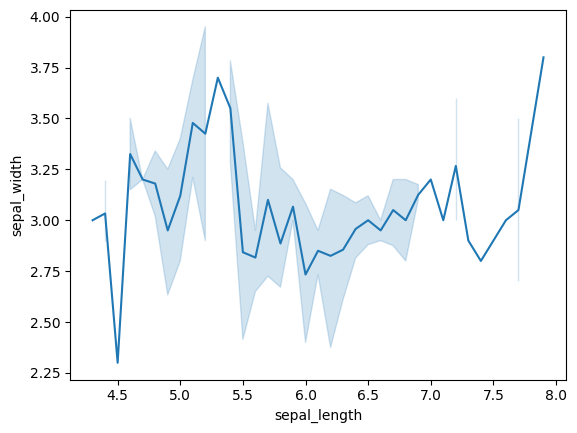

In [40]:
sns.lineplot(df, x='sepal_length', y='sepal_width')

In [34]:
%pip install ipympl


Note: you may need to restart the kernel to use updated packages.


In [39]:
# Try the following and the rerun the previous graph...
%matplotlib ipympl
import matplotlib.pyplot as plt


plt.plot([1,2,3])
plt.show()

RuntimeError: 'ipympl' is not a recognised GUI loop or backend name

**Task 1:**
Recreate the graph above, but use different columns for your x and y axis.

**Task 2:**
Choose another sample data set:
1. View just the first few rows to be able to understand its contents
2. Remove at least one column you do not consider relevant
3. Plot a significant relationship in that data set.


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   lower_pieces_length  150 non-null    float64
 1   lower_pieces_width   150 non-null    float64
 2   petal_length         150 non-null    float64
 3   petal_width          150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


<Axes: xlabel='petal_length', ylabel='petal_width'>

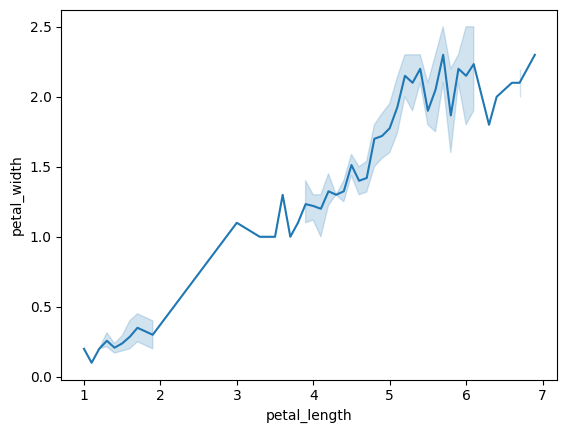

In [72]:
# Required libraries

import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path # modern library for working with the file system

# Constants
DATA_DIR = 'data/'
PATTERN = '*.csv'

df = sns.load_dataset('iris')
# now, we have us a standard pandas dataframe (df is just a conventional name)
df.head()

# if we wanted to suppress the output, we can with a semicolon:
df.head();

df.drop("species", axis=1) # axis 0 -  index (rows) or 1 - columns
# df.drop("species", axis='columns') # can also be stated as columns and index

df = df.drop('species', axis=1)
df.head()

# Sepals - also known as 3 lower drooping parts of an Iris
df = df.rename(columns={"sepal_length": "lower_pieces_length","sepal_width": "lower_pieces_width"})
df.info()
sns.lineplot(df, x='petal_length', y='petal_width', orient="x")


## Processing and extracting data from csv/Excel using pandas

While pandas is famous for its programmatic data analytics. For some tasks, it is significantly easier to use than Excel. 
Here we are going to combine a series of files in `csv` and then create basic pivot tables.

Portions of this section are based on:

[Extracting and pivoting data in pandas](https://www.youtube.com/watch?v=NqcPLp8a4Eg)

In [ ]:
# Constants
DATA_DIR = 'data/'
PATTERN = '*.csv'

### Preparation
1. Download the [files used in the video](https://github.com/jhnwr/auto-reporting)
2. Store them in a subdirectory called `data/`
3. Use the code below as a starting point for concatinating the data

In [62]:
# Process files and combine

for file in Path(DATA_DIR).glob(PATTERN):
    print(f"Processing file: {file}")


Processing file: data\report1.csv
Processing file: data\report2.csv
Processing file: data\report3.csv
Processing file: data\report4.csv
Processing file: data\report5.csv
Processing file: data\report6.csv
Processing file: data\report7.csv


In [66]:
# df = pd.read_csv(file, index_col=None, header=0)
data = [pd.read_csv(file, index_col=None, header=0) 
        for file in Path(DATA_DIR).glob(PATTERN)]

combined = pd.concat(data, axis=0, ignore_index=True)
   

In [75]:
result = combined
result.to_csv("results/output.csv", index=False)

result["date"] = pd.to_datetime(result["date"])

by_product = pd.pivot_table(result, index=["item", "size"], values=["qty"], aggfunc=sum)
by_country = pd.pivot_table(result, index=["country"], values=["qty"], aggfunc=sum)

by_product.to_csv("results/byproduct.csv")
by_country.to_csv("results/bycountry.csv")

In [90]:
report1 = pd.read_csv("data/report1.csv")

report1.head()
# now, we have us a standard pandas dataframe (df is just a conventional name)

# if we wanted to suppress the output, we can with a semicolon:
report1.drop("order_id", axis=1);

report1.head()

report1.info()
x_data = report1['qty']
# df = df.rename(columns={"sepal_length": "lower_pieces_length","sepal_width": "lower_pieces_width"})
# df.info()
#sns.(report1, x='petal_length', y='petal_width', orient="x")
#sns.regplot(x=x_data, scatter_kws={"color": "blue"})


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   order_id    1000 non-null   str  
 1   date        1000 non-null   str  
 2   email       1000 non-null   str  
 3   first_name  1000 non-null   str  
 4   last_name   1000 non-null   str  
 5   address     1000 non-null   str  
 6   country     1000 non-null   str  
 7   item        1000 non-null   str  
 8   size        1000 non-null   str  
 9   qty         1000 non-null   int64
dtypes: int64(1), str(9)
memory usage: 78.3 KB
